In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [3]:
from datetime import datetime, timedelta

import polars as pl

from tests.helpers.collector import PolarsCollector
from tests.helpers.simulation_runner import SimulationTestRunner
from thrs.classes.machine_state_logger import MachineStateLoggingServiceNoop
from thrs.control.modules.drives import (
    DrivesControl,
    DrivesParameters,
)
from thrs.input_output.alarms import BaseAlarms
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    Boundary,
    Converter,
    HeatSource,
    PropulsionDrive,
)
from thrs.input_output.modules.drives import (
    DrivesControlValues,
    DrivesSensorValues,
    DrivesSimulationInputs,
    DrivesSimulationOutputs,
)
from thrs.orchestration.simulation import Simulation
from thrs.simulation.fmu import Fmu
from thrs.simulation.models.fmu_paths import drives_path

start_time = datetime.fromtimestamp(0)
minutes = 20
duration = timedelta(minutes=minutes - 1)
time_index = pl.datetime_range(
    start_time,
    start_time + duration,
    interval="1m",
    time_unit="us",
    eager=True,
)

SEAWATER_TEMPERATURE = 20.0

simulation_inputs = DrivesSimulationInputs(
    drives_oil_cooler_aft=HeatSource(heat_flow=Stamped.stamp(0)),
    drives_oil_cooler_fwd=HeatSource(heat_flow=Stamped.stamp(0)),
    drives_propdrive_aft1=PropulsionDrive(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    drives_propdrive_aft2=PropulsionDrive(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    drives_propdrive_fwd1=PropulsionDrive(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    drives_propdrive_fwd2=PropulsionDrive(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    drives_shorepower=Converter(
        heat_flow=Stamped.stamp(15000), active=Stamped.stamp(True)
    ),
    drives_seawater_supply=Boundary(
        temperature=Stamped.stamp(SEAWATER_TEMPERATURE), flow=Stamped.stamp(64)
    ),
    drives_dhw_supply=Boundary(temperature=Stamped.stamp(20), flow=Stamped.stamp(29)),
)

parameters = DrivesParameters(
    shorepower_maximum_supply_temperature=90,
    propulsion_maximum_supply_temperature=60,
    recovery_temperature=50,
    shorepower_flow_setpoint=20,
    propulsion_drives_flow_setpoint=30,
    recovery_mix_tuning=(-0.1, -0.0005, 0),
)

with Fmu(drives_path) as fmu:
    simulation = Simulation(
        DrivesSensorValues,
        DrivesSimulationOutputs,
        fmu,
        simulation_inputs,
        start_time,
        timedelta(seconds=1),
    )
    control = DrivesControl(
        parameters, simulation.time, MachineStateLoggingServiceNoop()
    )
    runner = SimulationTestRunner(simulation, control, BaseAlarms())
    collector = PolarsCollector()
    runner.run(int(duration.total_seconds()), collector)
    result = collector.result()

[WARNING] State logging: Please enable result storing to get state names


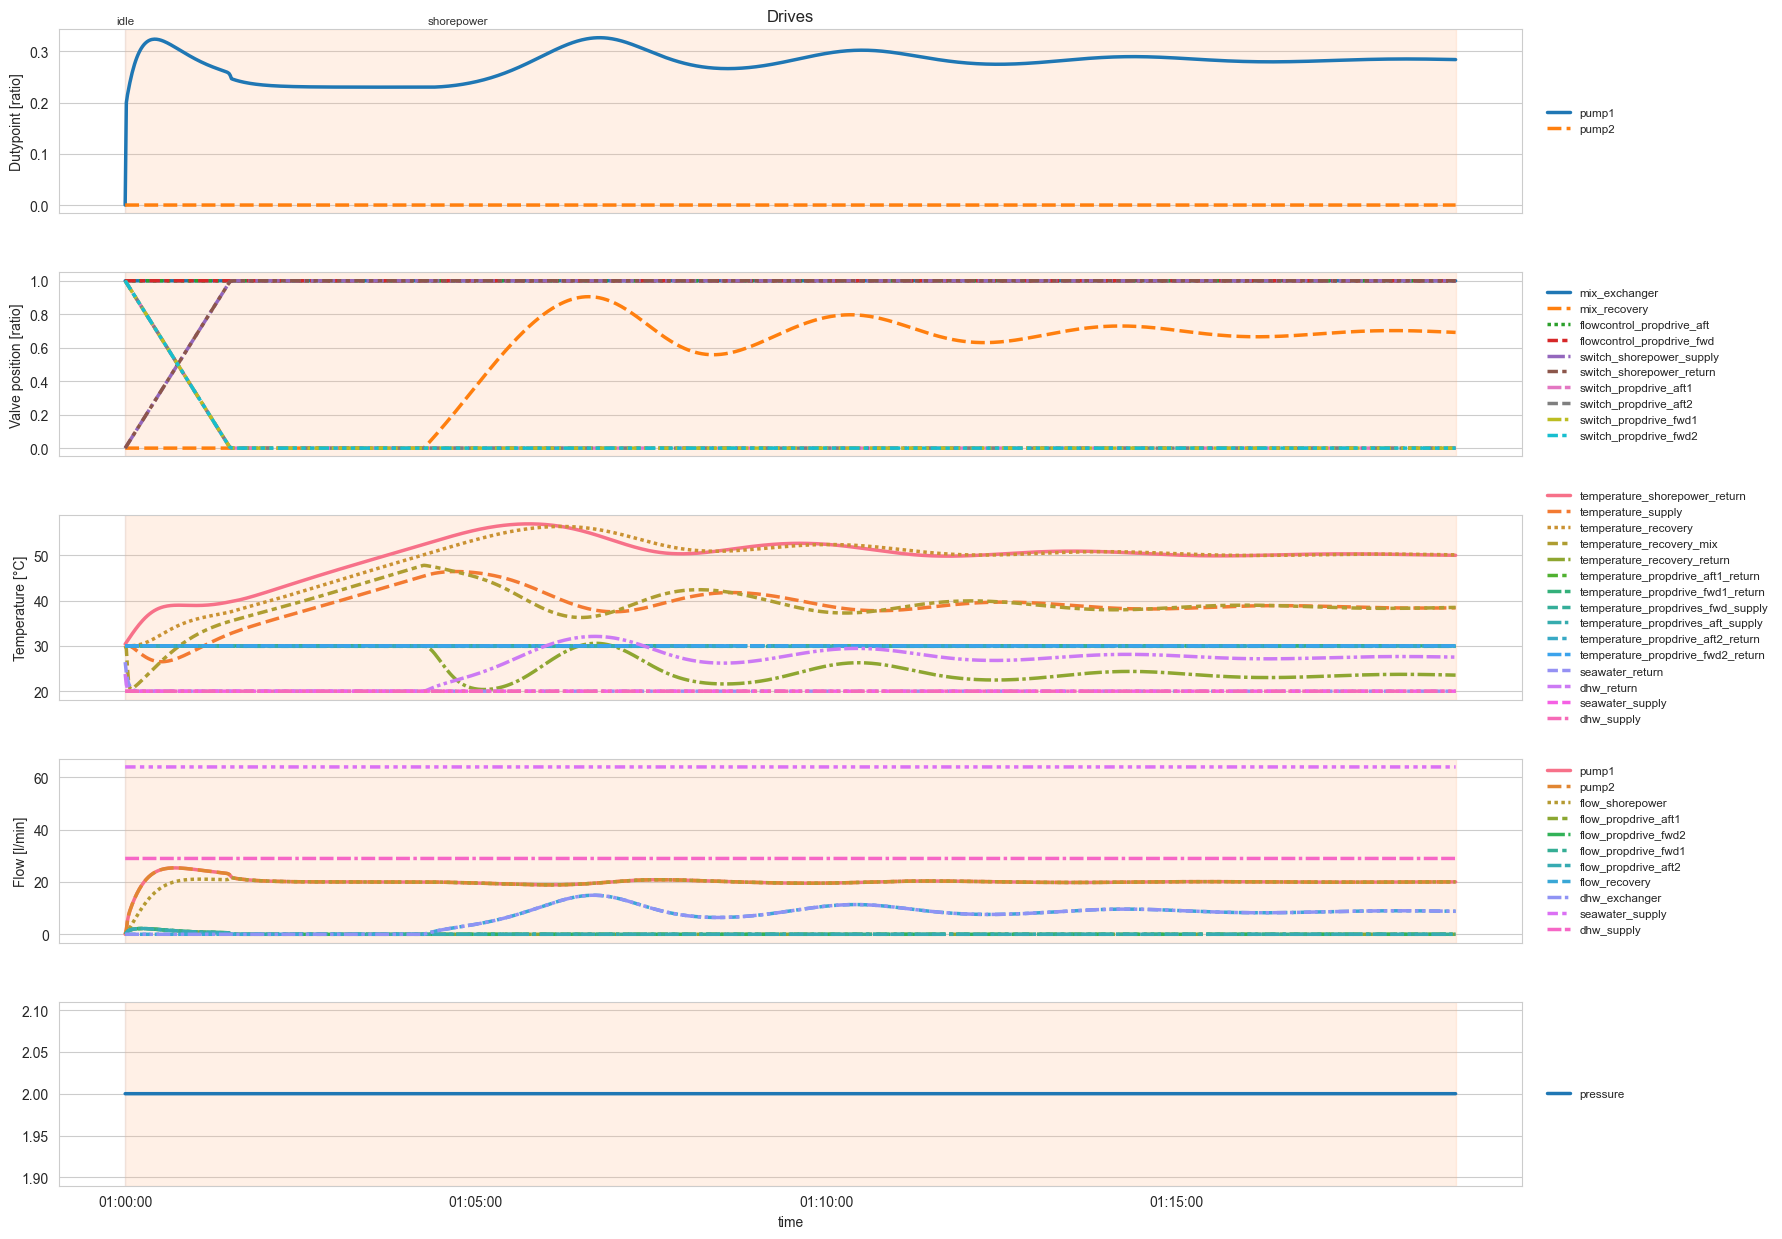

In [4]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/dc.png");

In [ ]:
from thrs.simulation.io_mapping import build_fmu_key_mapping

result.select(
    [
        "time",
        *build_fmu_key_mapping(DrivesControlValues, fmu_only=False).values(),
        *build_fmu_key_mapping(DrivesSimulationInputs, fmu_only=False).values(),
    ]
).write_csv("csv/drives_run_inputs.csv")


result.select(
    [
        "time",
        *build_fmu_key_mapping(DrivesSensorValues, fmu_only=False).values(),
        *build_fmu_key_mapping(DrivesSimulationOutputs, fmu_only=False).values(),
    ]
).write_csv("csv/drives_run_outputs.csv")